In [7]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# =====================================================
# 0. CONFIGURATION & SEEDS 
# =====================================================
MODEL_PATH = "../../models/stroke_mvp.pth"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
generator = torch.Generator().manual_seed(SEED)

# =====================================================
# 1. DATASET LOCATION
# =====================================================

# Original dataset source:
# https://www.kaggle.com/datasets/abdussalamelhanashy/annotated-facial-images-for-stroke-classification

dataset_root = Path("../../dataset/annotated_stroke_and_nonstroke")

if not dataset_root.exists():
    raise FileNotFoundError(f"Dataset not found.")

print(f"✅ SUCCESS: Dataset found.")

✅ SUCCESS: Dataset found.


In [39]:
# =====================================================
# 2. IMAGE PREPROCESSING & DATA LOAD
# =====================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(dataset_root, transform=transform)
class_names = full_dataset.classes

# =====================================================
# 3. RECREATE EXACT 80/20 SPLIT
# =====================================================
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Generator seed guarantees this split matches the training script exactly
_, val_data = random_split(full_dataset, [train_size, val_size], generator=generator)

val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
print(f"Evaluating on {len(val_data)} held-out validation images...\n")


Evaluating on 750 held-out validation images...



In [40]:
# =====================================================
# 4. MODEL DEFINITION
# =====================================================
class SimpleStrokeCNN(nn.Module):
    def __init__(self):
        super(SimpleStrokeCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(128 * 14 * 14, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.dropout(self.pool(F.relu(self.conv1(x))))
        x = self.dropout(self.pool(F.relu(self.conv2(x))))
        x = self.dropout(self.pool(F.relu(self.conv3(x))))
        x = self.dropout(self.pool(F.relu(self.conv4(x))))

        x = x.view(-1, 128 * 14 * 14)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# =====================================================
# 5. LOAD TRAINED MODEL
# =====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f" ERROR: Could not find '{MODEL_PATH}'. Run the training script first.")

model = SimpleStrokeCNN().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()


SimpleStrokeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=25088, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)

In [41]:
# =====================================================
# 6. EVALUATION LOOP
# =====================================================
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

# =====================================================
# 7. METRICS & REPORTING
# =====================================================
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("========== FINAL RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


========== FINAL RESULTS ==========
Accuracy : 0.9987
Precision: 0.9958
Recall   : 1.0000
F1 Score : 0.9979
ROC-AUC  : 0.9999

Classification Report:
              precision    recall  f1-score   support

   NonStroke       1.00      1.00      1.00       513
      Stroke       1.00      1.00      1.00       237

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



Confusion Matrix:
[[512   1]
 [  0 237]]


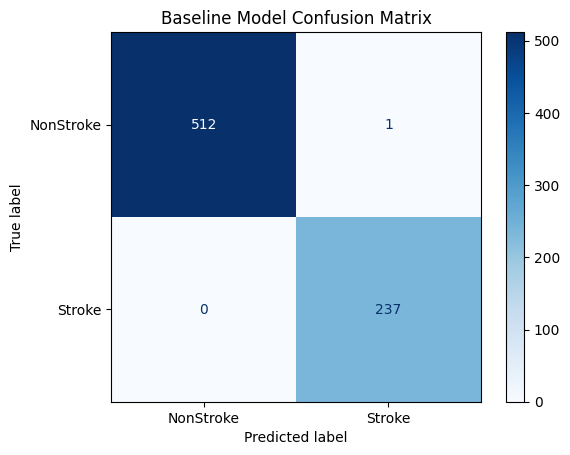

In [42]:
# =====================================================
# 8. CONFUSION MATRIX VISUALIZATION
# =====================================================
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
plt.title("Baseline Model Confusion Matrix")
plt.show()